# Project Overview

Notebook ini membahas pengembangan model machine learning untuk memprediksi pembatalan reservasi hotel menggunakan dataset *Hotel Booking Demand* yang tersedia secara publik di Kaggle. Analisis difokuskan pada pemahaman pola pembatalan dan pembangunan sistem prediktif yang dapat mendukung pengambilan keputusan operasional dan revenue management di industri perhotelan.

Dataset yang digunakan dapat diakses melalui tautan berikut:  
https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

---

## Latar Belakang Masalah
Pembatalan reservasi hotel merupakan salah satu sumber utama ketidakpastian permintaan. Tingginya tingkat pembatalan dapat menimbulkan berbagai permasalahan operasional, antara lain:
- Kesulitan dalam memprediksi tingkat okupansi secara akurat
- Risiko penetapan kebijakan overbooking yang tidak optimal
- Potensi kehilangan pendapatan akibat kamar kosong
- Inefisiensi dalam perencanaan sumber daya dan operasional hotel

Tanpa sistem prediktif yang memadai, pihak hotel berisiko menghadapi pembatalan mendadak yang berdampak langsung pada performa bisnis.

---

## Tujuan Project
Tujuan dari proyek ini adalah membangun model *supervised classification* untuk memprediksi apakah suatu reservasi hotel berpotensi dibatalkan atau tidak.

Lima algoritma machine learning yang akan dievaluasi dalam proyek ini adalah:
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest
- AdaBoost

### Metrik Evaluasi
- **Recall** digunakan sebagai metrik utama untuk memaksimalkan kemampuan model dalam mendeteksi reservasi yang benar-benar akan dibatalkan. Hal ini penting untuk meminimalkan risiko pembatalan yang tidak terantisipasi.
- **ROC-AUC** digunakan untuk mengevaluasi kemampuan model dalam membedakan antara reservasi yang dibatalkan dan tidak dibatalkan pada berbagai threshold, sehingga memungkinkan perbandingan performa antarmodel secara lebih objektif.

---

## Pengguna dan Pemangku Kepentingan
Hasil dari proyek ini ditujukan untuk mendukung:
- Manajer hotel dan staf operasional dalam pengelolaan alokasi kamar dan pemantauan okupansi
- Tim revenue management dalam penyusunan strategi harga dan kebijakan overbooking
- Analis data internal hotel sebagai alat bantu pengambilan keputusan berbasis data

# Import Libraries

In [ ]:
# Data manipulation and numerical computation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Model evaluation
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV

# Model persistence
import pickle

# Miscellaneous
import warnings
warnings.filterwarnings("ignore")

# Data Preparation

## Data Loading

In [2]:
data = pd.read_csv("./Dataset/hotel_bookings.csv")
pd.set_option("display.max_columns", None)

data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
data.shape, data.duplicated().sum()

((119390, 32), 31994)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## Data Understanding

Dataset terdiri dari 119.390 baris dan 32 kolom yang merepresentasikan informasi reservasi hotel, mencakup karakteristik pelanggan, detail pemesanan, serta status reservasi.

Berdasarkan eksplorasi awal, ditemukan beberapa kondisi penting:
- Terdapat **data duplikat sebanyak 31.994 baris** yang perlu dihapus untuk menghindari bias pada proses pelatihan model.
- Ditemukan **missing values** pada kolom `children`, `country`, `agent`, dan `company`.
- Kolom `children` masih memiliki tipe data numerik desimal yang perlu disesuaikan setelah proses penanganan missing values.
- Kolom `reservation_status` dan `reservation_status_date` akan **dihapus** karena mengandung informasi pasca-kejadian yang berpotensi menyebabkan *data leakage* terhadap target `is_canceled`.

Temuan ini menjadi dasar untuk proses *data cleaning* dan *feature engineering* pada tahap selanjutnya.

## Data Cleaning
Tahap data cleaning dilakukan untuk memastikan kualitas data sebelum proses eksplorasi lanjutan dan pemodelan. Fokus utama pada tahap ini meliputi penghapusan data duplikat, pencegahan data leakage, serta standarisasi nilai pada fitur kategorikal.

In [6]:
# Menghapus data duplikat untuk mencegah bias pada proses training
data = data.drop_duplicates()

data.shape

(87396, 32)

In [7]:
# Menghapus kolom yang mengandung informasi pasca-kejadian untuk mencegah data leakage terhadap target
data = data.drop(
    columns=["reservation_status", "reservation_status_date"]
)

In [8]:
# Standarisasi kolom kategorikal untuk menjaga konsistensi nilai teks
categorical_columns = [
    "hotel",
    "arrival_date_month",
    "meal",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type"
]

for col in categorical_columns:
    data[col] = data[col].astype(str).str.lower().str.strip()

In [9]:
# Backup Dataset
data_backup = data.copy()

# Exploratory Data Analysis (EDA)

## Distribusi Target Pembatalan  
Analisis ini dilakukan untuk memahami distribusi kelas pada target `is_canceled` dan menentukan metrik evaluasi yang sesuai untuk proses pemodelan.

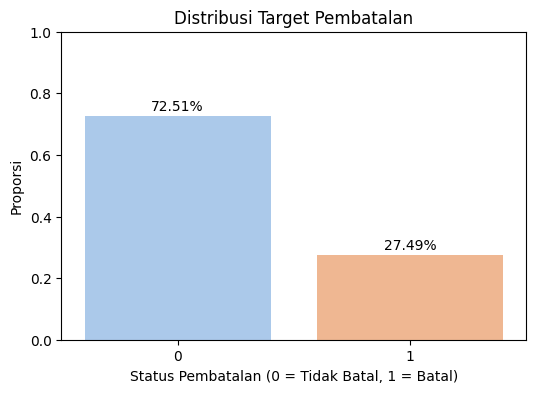

In [10]:
# Distribusi target pembatalan
target_dist = data["is_canceled"].value_counts(normalize=True)

plt.figure(figsize=(6,4))
sns.barplot(
    x=target_dist.index.astype(str),
    y=target_dist.values,
    palette="pastel"
)
plt.title("Distribusi Target Pembatalan")
plt.xlabel("Status Pembatalan (0 = Tidak Batal, 1 = Batal)")
plt.ylabel("Proporsi")
plt.ylim(0,1)

for i, v in enumerate(target_dist.values):
    plt.text(i, v + 0.02, f"{v:.2%}", ha="center")

plt.show()

**Insight :**  
Berdasarkan hasil visualisasi, sekitar **27–28% reservasi mengalami pembatalan**, sementara sisanya tidak dibatalkan. Distribusi ini menunjukkan bahwa dataset memiliki **ketidakseimbangan kelas**, sehingga metrik evaluasi seperti *accuracy* kurang representatif.

Oleh karena itu, **recall** dipilih sebagai metrik utama untuk memaksimalkan kemampuan model dalam mendeteksi kasus pembatalan, yang secara bisnis lebih berisiko apabila tidak teridentifikasi.

## Hubungan Lead Time dengan Pembatalan Reservasi  
Fitur `lead_time` merepresentasikan jarak waktu (dalam hari) antara tanggal pemesanan dan tanggal kedatangan tamu. Secara bisnis, pemesanan yang dilakukan jauh hari sebelumnya berpotensi memiliki ketidakpastian lebih tinggi dan peluang pembatalan yang lebih besar dibandingkan pemesanan mendekati tanggal kedatangan.

EDA ini dilakukan untuk:
- Memahami perbedaan distribusi lead time antara reservasi yang dibatalkan dan tidak dibatalkan
- Menilai apakah lead time merupakan fitur yang relevan dan informatif untuk proses pemodelan
- Menentukan apakah diperlukan perlakuan khusus seperti transformasi atau binning pada fitur ini


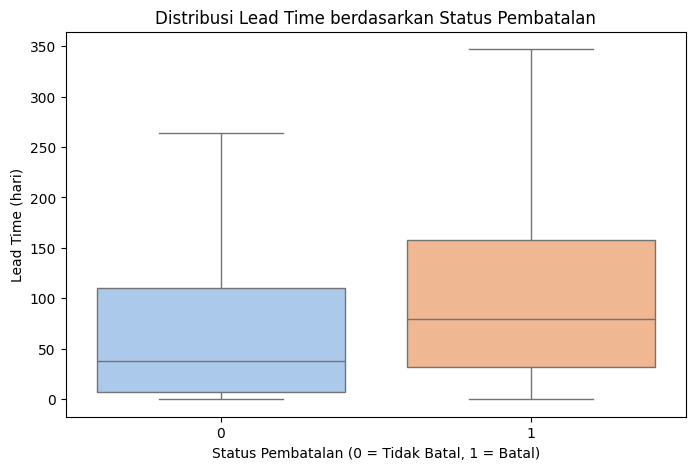

In [11]:
# Distribusi lead time berdasarkan status pembatalan
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x="is_canceled",
    y="lead_time",
    showfliers=False,
    palette="pastel"
)

plt.title("Distribusi Lead Time berdasarkan Status Pembatalan")
plt.xlabel("Status Pembatalan (0 = Tidak Batal, 1 = Batal)")
plt.ylabel("Lead Time (hari)")

plt.show()

**Insight :**  
Berdasarkan visualisasi di atas, terlihat bahwa reservasi yang **dibatalkan** memiliki **median lead time yang lebih tinggi** dibandingkan reservasi yang tidak dibatalkan. Hal ini menunjukkan bahwa pemesanan yang dilakukan jauh hari sebelum tanggal kedatangan cenderung memiliki probabilitas pembatalan yang lebih besar.

Perbedaan distribusi ini mengindikasikan bahwa `lead_time` merupakan fitur numerik yang informatif dan berpotensi kuat dalam memprediksi pembatalan reservasi. Oleh karena itu, fitur ini akan dipertahankan dalam proses pemodelan dan dipertimbangkan lebih lanjut pada tahap feature engineering.

## Hubungan Deposit Type dengan Pembatalan Reservasi  
Fitur **`deposit_type`** merepresentasikan kebijakan pembayaran deposit yang diterapkan pada saat pemesanan. Kebijakan ini berpotensi memengaruhi perilaku tamu dalam melakukan pembatalan, karena adanya konsekuensi finansial yang berbeda pada setiap tipe deposit.

EDA ini dilakukan dengan tujuan untuk:
- Menganalisis perbedaan jumlah reservasi yang dibatalkan dan tidak dibatalkan pada setiap tipe deposit
- Membandingkan tingkat pembatalan (*cancellation rate*) antar tipe deposit
- Menilai relevansi fitur `deposit_type` sebagai fitur kategorikal yang berpotensi kuat dalam memprediksi pembatalan reservasi

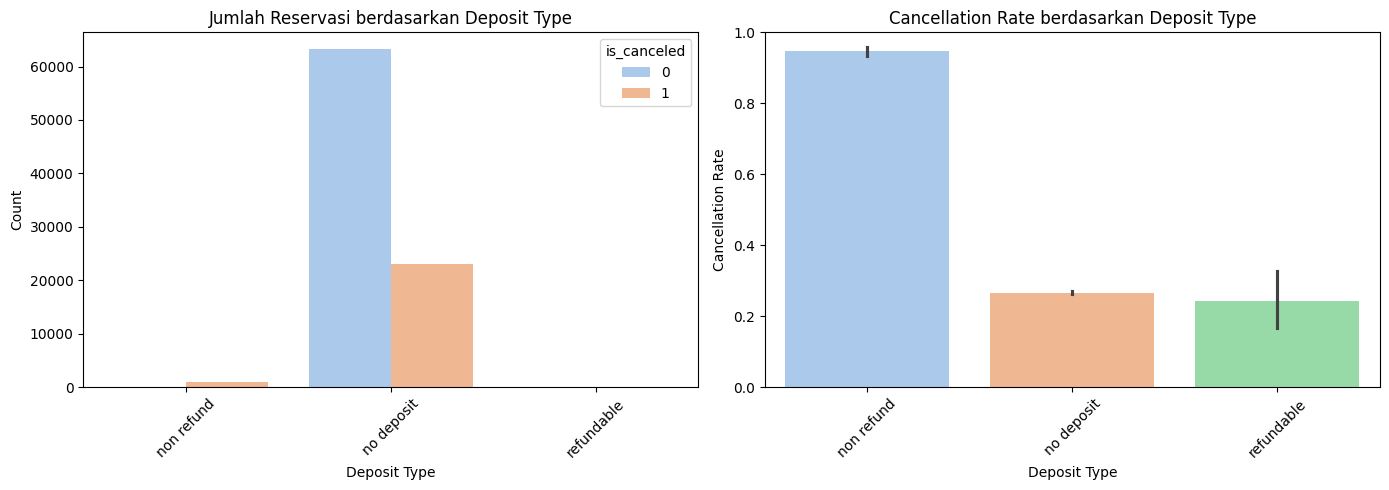

In [12]:
# Urutan deposit berdasarkan cancellation rate
deposit_order = (
    data.groupby("deposit_type")["is_canceled"]
        .mean()
        .sort_values(ascending=False)
        .index
)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Jumlah booking berdasarkan deposit type
sns.countplot(
    data=data,
    x="deposit_type",
    hue="is_canceled",
    order=deposit_order,
    palette="pastel",
    ax=axes[0]
)
axes[0].set_title("Jumlah Reservasi berdasarkan Deposit Type")
axes[0].set_xlabel("Deposit Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Cancellation rate berdasarkan deposit type
sns.barplot(
    data=data,
    x="deposit_type",
    y="is_canceled",
    order=deposit_order,
    palette="pastel",
    ax=axes[1]
)
axes[1].set_title("Cancellation Rate berdasarkan Deposit Type")
axes[1].set_xlabel("Deposit Type")
axes[1].set_ylabel("Cancellation Rate")
axes[1].set_ylim(0,1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Insight :**  
Berdasarkan visualisasi, terdapat perbedaan yang sangat jelas pada tingkat pembatalan reservasi di antara berbagai tipe deposit. Reservasi dengan tipe **non refund** memiliki *cancellation rate* yang paling tinggi dibandingkan tipe deposit lainnya, meskipun jumlah reservasinya relatif kecil. Hal ini mengindikasikan bahwa reservasi dengan kebijakan non-refund justru memiliki risiko pembatalan yang sangat tinggi.  

Sebaliknya, reservasi dengan tipe **no deposit** merupakan mayoritas dari total pemesanan, namun memiliki *cancellation rate* yang relatif lebih rendah. Kondisi ini menunjukkan bahwa meskipun tidak ada kewajiban deposit di awal, sebagian besar tamu tetap melanjutkan reservasinya hingga tanggal kedatangan.  

Untuk tipe **refundable**, jumlah reservasi tergolong sangat kecil, namun tingkat pembatalannya berada pada kisaran menengah dibandingkan tipe deposit lainnya. Hal ini menunjukkan bahwa fleksibilitas pengembalian dana tidak selalu berbanding lurus dengan tingginya tingkat pembatalan.  

Secara keseluruhan, hasil EDA ini mengindikasikan bahwa **`deposit_type` merupakan fitur kategorikal yang sangat informatif** dan berpotensi kuat dalam memprediksi pembatalan reservasi. Oleh karena itu, fitur ini akan dipertahankan dan dipertimbangkan secara serius dalam proses pemodelan.

## Hubungan Market Segment dengan Pembatalan Reservasi
Fitur **`market_segment`** merepresentasikan kanal atau segmen pasar tempat reservasi dilakukan, seperti *online travel agent*, *offline travel agent*, *direct booking*, dan segmen lainnya. Setiap segmen memiliki karakteristik perilaku pelanggan yang berbeda, termasuk dalam hal fleksibilitas dan kecenderungan melakukan pembatalan.

EDA ini dilakukan dengan tujuan untuk:
- Menganalisis perbedaan jumlah reservasi yang dibatalkan dan tidak dibatalkan pada setiap market segment
- Membandingkan tingkat pembatalan (*cancellation rate*) antar market segment
- Menilai apakah fitur `market_segment` memiliki pengaruh yang signifikan dan layak dipertahankan sebagai fitur kategorikal dalam pemodelan pembatalan reservasi

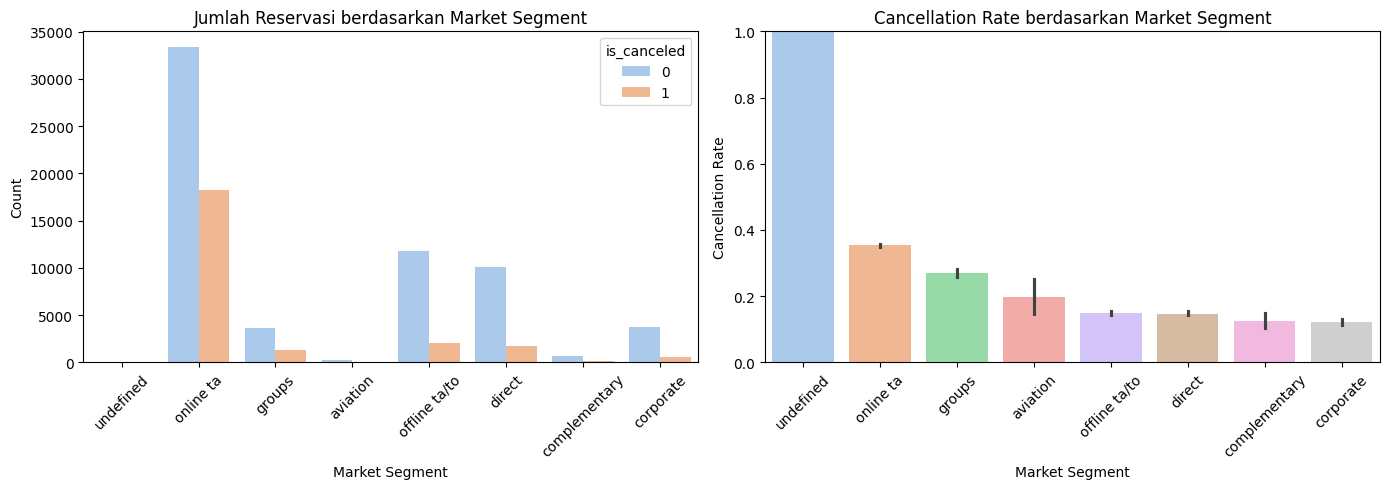

In [13]:
# Urutan market segment berdasarkan cancellation rate
segment_order = (
    data.groupby("market_segment")["is_canceled"]
        .mean()
        .sort_values(ascending=False)
        .index
)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Jumlah reservasi berdasarkan market segment
sns.countplot(
    data=data,
    x="market_segment",
    hue="is_canceled",
    order=segment_order,
    palette="pastel",
    ax=axes[0]
)
axes[0].set_title("Jumlah Reservasi berdasarkan Market Segment")
axes[0].set_xlabel("Market Segment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Cancellation rate berdasarkan market segment
sns.barplot(
    data=data,
    x="market_segment",
    y="is_canceled",
    order=segment_order,
    palette="pastel",
    ax=axes[1]
)
axes[1].set_title("Cancellation Rate berdasarkan Market Segment")
axes[1].set_xlabel("Market Segment")
axes[1].set_ylabel("Cancellation Rate")
axes[1].set_ylim(0,1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Insight :**  
Berdasarkan visualisasi, terdapat perbedaan yang cukup signifikan pada tingkat pembatalan reservasi di antara berbagai **market segment**. Segmen **online TA** memiliki jumlah reservasi paling besar, sekaligus menunjukkan *cancellation rate* yang relatif tinggi dibandingkan beberapa segmen lainnya. Hal ini mengindikasikan bahwa meskipun kanal ini mendominasi volume pemesanan, risiko pembatalannya juga perlu mendapat perhatian khusus.

Segmen **groups** juga menunjukkan tingkat pembatalan yang cukup tinggi meskipun jumlah reservasinya lebih kecil dibandingkan online TA. Hal ini mengisyaratkan bahwa pemesanan berbasis kelompok memiliki karakteristik risiko pembatalan yang lebih besar dibandingkan pemesanan individual.

Sebaliknya, segmen seperti **direct**, **offline TA/TO**, dan **corporate** memiliki *cancellation rate* yang relatif lebih rendah. Kondisi ini menunjukkan bahwa pemesanan melalui kanal-kanal tersebut cenderung lebih stabil dan memiliki kepastian yang lebih tinggi.

Sementara itu, segmen **undefined** menunjukkan *cancellation rate* yang sangat tinggi, namun jumlah observasinya sangat kecil. Oleh karena itu, segmen ini perlu diperlakukan dengan hati-hati pada tahap pemodelan agar tidak menimbulkan bias.

Secara keseluruhan, hasil EDA ini menunjukkan bahwa **`market_segment` merupakan fitur kategorikal yang informatif**, namun memerlukan perhatian khusus terkait ketidakseimbangan jumlah data antar kategori dan potensi perlakuan khusus pada segmen dengan observasi yang sangat terbatas.

# Feature Engineering

In [14]:
# Memisahkan fitur (X) dan target (y)
X = data.drop(columns=['is_canceled'])
y = data['is_canceled']

## Train–Test Split

Dataset dibagi menjadi **data latih (train set)** dan **data uji (test set)** untuk memastikan bahwa evaluasi performa model dilakukan pada data yang benar-benar belum pernah dilihat sebelumnya.

Pembagian data dilakukan dengan:
- Proporsi **80% data latih** dan **20% data uji**
- Parameter `stratify=y` untuk menjaga proporsi kelas pembatalan pada kedua subset, mengingat target bersifat tidak seimbang
- `random_state` digunakan agar hasil dapat direproduksi

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Proporsi target di train set:")
print(y_train.value_counts(normalize=True))
print("Proporsi target di test set:")
print(y_test.value_counts(normalize=True))

Ukuran X_train: (69916, 29)
Ukuran X_test : (17480, 29)
Proporsi target di train set:
is_canceled
0    0.725099
1    0.274901
Name: proportion, dtype: float64
Proporsi target di test set:
is_canceled
0    0.725114
1    0.274886
Name: proportion, dtype: float64


## Penanganan Missing Values
Beberapa fitur dalam dataset memiliki nilai hilang (*missing values*), khususnya pada kolom `children`, `agent`, dan `company`. Penanganan dilakukan berdasarkan konteks bisnis dan karakteristik fitur, bukan semata-mata pertimbangan statistik.


### Ringkasan Missing Values

Sebelum melakukan imputasi, dilakukan pengecekan persentase *missing values* pada setiap fitur untuk memahami tingkat kelengkapan data. Analisis ini bersifat deskriptif dan tidak melibatkan target, sehingga aman dilakukan sebelum proses pemodelan.

In [16]:
# Ringkasan persentase missing values
missing_summary = (
    X_train.isnull()
    .mean()
    .sort_values(ascending=False)
)

missing_summary[missing_summary > 0]

company     0.939670
agent       0.139239
country     0.005278
children    0.000057
dtype: float64

### Strategi Penanganan Missing Values

Strategi imputasi ditentukan berdasarkan konteks fitur:

- `children`: missing value diinterpretasikan sebagai tidak membawa anak, sehingga diimputasi dengan nilai 0
- `agent` dan `company`: merupakan identifier reservasi. Nilai hilang menunjukkan reservasi tidak melalui agen atau perusahaan tertentu, sehingga diimputasi dengan nilai 0 sebagai label *Unknown*
- `country`: missing value diimputasi sebagai kategori `unknown` untuk merepresentasikan negara asal yang tidak tercatat

Pendekatan ini dipilih untuk menjaga konsistensi data tanpa menghilangkan informasi penting.

In [17]:
X_train = X_train.copy()
X_test = X_test.copy()

# children
X_train['children'] = X_train['children'].fillna(0)
X_test['children'] = X_test['children'].fillna(0)

# agent & company (identifier → unknown = 0)
for col in ['agent', 'company']:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

# country (kategori eksplisit)
X_train['country'] = X_train['country'].fillna('unknown')
X_test['country'] = X_test['country'].fillna('unknown')

# konsistensi tipe data
X_train['children'] = X_train['children'].astype(int)
X_test['children'] = X_test['children'].astype(int)

# agent & company disiapkan sebagai kategori
X_train['agent'] = X_train['agent'].astype(str)
X_test['agent'] = X_test['agent'].astype(str)

X_train['company'] = X_train['company'].astype(str)
X_test['company'] = X_test['company'].astype(str)

# verifikasi akhir
print("Missing values X_train:", X_train.isnull().sum().sum())
print("Missing values X_test :", X_test.isnull().sum().sum())

Missing values X_train: 0
Missing values X_test : 0


## Analisis Cardinality Fitur Kategorikal

Setelah proses penanganan missing values, langkah selanjutnya adalah menganalisis
tingkat cardinality pada fitur-fitur kategorikal.

Cardinality yang tinggi dapat menyebabkan:
- Ledakan jumlah fitur setelah proses encoding
- Waktu training model yang sangat lama
- Risiko overfitting akibat fitur yang terlalu jarang (*sparse*)

Analisis ini dilakukan pada **data training saja** untuk menghindari data leakage
dan menjadi dasar dalam menentukan strategi penanganan cardinality selanjutnya.

In [18]:
# Fitur numerik
num_features = [
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

# Fitur kategorikal
cat_features = [
    'hotel',
    'arrival_date_month',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'country',
    'agent',
    'company'
]

In [19]:
# Cek cardinality fitur kategorikal pada data training
cardinality_summary = (
    X_train[cat_features]
    .nunique()
    .sort_values(ascending=False)
)

cardinality_summary

company                 328
agent                   322
country                 171
arrival_date_month       12
assigned_room_type       11
reserved_room_type       10
market_segment            8
meal                      5
distribution_channel      5
customer_type             4
deposit_type              3
hotel                     2
dtype: int64

### Hasil Analisis Cardinality Fitur Kategorikal

Berdasarkan hasil pengecekan jumlah nilai unik (*cardinality*) pada fitur-fitur kategorikal di data training, diperoleh ringkasan sebagai berikut:

- `company` memiliki **328 kategori unik**
- `agent` memiliki **322 kategori unik**
- `country` memiliki **171 kategori unik**
- Fitur kategorikal lainnya memiliki cardinality relatif rendah (≤12 kategori)

Tingginya cardinality pada kolom `company`, `agent`, dan `country` mengindikasikan bahwa ketiga fitur tersebut berpotensi menimbulkan permasalahan pada tahap encoding, seperti:
- Ledakan jumlah fitur setelah proses *One-Hot Encoding*
- Waktu pelatihan model yang jauh lebih lama, terutama saat *cross validation*
- Risiko *overfitting* akibat banyaknya kategori dengan frekuensi sangat rendah

Sebaliknya, fitur kategorikal lain seperti `hotel`, `deposit_type`, dan `customer_type` memiliki jumlah kategori yang kecil dan relatif stabil, sehingga aman untuk langsung dilakukan encoding tanpa perlakuan khusus.

Oleh karena itu, fitur `company`, `agent`, dan `country` akan mendapatkan perlakuan khusus berupa **reduksi cardinality** sebelum proses encoding, sementara fitur kategorikal lainnya akan dipertahankan sebagaimana adanya.

### Penanganan Cardinality Fitur Kategorikal

Beberapa fitur kategorikal memiliki jumlah kategori yang sangat tinggi (*high cardinality*), khususnya
`country`, `agent`, dan `company`. Jika fitur-fitur ini langsung dilakukan *One-Hot Encoding* tanpa
perlakuan khusus, maka akan terjadi ledakan jumlah fitur yang berdampak pada:

- Waktu pelatihan model yang sangat lama
- Kompleksitas model yang berlebihan
- Risiko overfitting akibat banyaknya kategori dengan frekuensi sangat rendah

Untuk mengatasi hal tersebut, dilakukan **reduksi cardinality** dengan pendekatan *Top-N Categories*,
di mana hanya kategori dengan frekuensi tertinggi yang dipertahankan, sementara kategori lainnya
digabungkan ke dalam label `OTHER`.

Proses ini dilakukan **hanya pada data training** untuk menghindari data leakage, dan hasil pemetaan
kemudian diaplikasikan secara konsisten ke data testing.

In [20]:
# Tentukan jumlah kategori teratas
TOP_N = 10

# Ambil top-N category dari TRAIN SET SAJA
top_country = X_train['country'].value_counts().nlargest(TOP_N).index
top_agent = X_train['agent'].value_counts().nlargest(TOP_N).index
top_company = X_train['company'].value_counts().nlargest(TOP_N).index

In [21]:
def reduce_cardinality(series, top_values, other_label):
    """
    Mengelompokkan kategori di luar top-N menjadi label 'OTHER'
    """
    return series.apply(lambda x: x if x in top_values else other_label)

In [22]:
# Apply ke TRAIN
X_train['country'] = reduce_cardinality(X_train['country'], top_country, 'OTHER_COUNTRY')
X_train['agent'] = reduce_cardinality(X_train['agent'], top_agent, 'OTHER_AGENT')
X_train['company'] = reduce_cardinality(X_train['company'], top_company, 'OTHER_COMPANY')

# Apply ke TEST (pakai mapping dari TRAIN)
X_test['country'] = reduce_cardinality(X_test['country'], top_country, 'OTHER_COUNTRY')
X_test['agent'] = reduce_cardinality(X_test['agent'], top_agent, 'OTHER_AGENT')
X_test['company'] = reduce_cardinality(X_test['company'], top_company, 'OTHER_COMPANY')

In [23]:
# Cek ulang cardinality setelah reduksi
X_train[['country', 'agent', 'company']].nunique()

country    11
agent      11
company    11
dtype: int64

## Analisis dan Penanganan Outlier

Outlier pada fitur numerik berpotensi memengaruhi performa model, terutama pada algoritma
yang sensitif terhadap skala dan jarak seperti **K-Nearest Neighbors (KNN)** dan
**Support Vector Machine (SVM)**. Namun, tidak semua nilai ekstrem dapat langsung dianggap
sebagai kesalahan data (*noise*), karena dalam konteks bisnis perhotelan beberapa nilai
ekstrem masih dapat merepresentasikan kondisi yang valid.

Oleh karena itu, penanganan outlier pada proyek ini tidak dilakukan secara langsung,
melainkan diawali dengan analisis eksploratif untuk memahami karakteristik distribusi
masing-masing fitur numerik.

Tahapan yang akan dilakukan pada analisis outlier meliputi:
1. Menghitung **skewness** untuk mengidentifikasi distribusi data yang condong (skewed)
2. Mengestimasi **proporsi outlier** menggunakan pendekatan *Interquartile Range (IQR)*
3. Melakukan **visualisasi distribusi** menggunakan histogram dan boxplot
4. Menentukan apakah outlier perlu ditangani berdasarkan konteks data dan potensi
   dampaknya terhadap model

Jika outlier dinilai berpotensi mengganggu stabilitas model, maka akan diterapkan
pendekatan **winsorization**, yaitu membatasi nilai ekstrem pada ambang tertentu tanpa
menghapus observasi. Pendekatan ini dipilih untuk menjaga ukuran dataset tetap utuh
sekaligus mengurangi pengaruh nilai ekstrem yang tidak proporsional.

In [24]:
# Analisis skewness fitur numerik pada data training
skewness_summary = (
    X_train[num_features]
    .skew()
    .sort_values(ascending=False)
    .reset_index()
)

skewness_summary.columns = ['feature', 'skewness']

# Klasifikasi distribusi
skewness_summary['distribution'] = skewness_summary['skewness'].apply(
    lambda x: 'normal' if -0.5 <= x <= 0.5 else 'skewed'
)

skewness_summary

,feature,skewness,distribution
0,adults,15.574601,skewed
1,children,3.473553,skewed
2,required_car_parking_spaces,3.330539,skewed
3,stays_in_week_nights,2.670052,skewed
4,lead_time,1.435329,skewed
5,stays_in_weekend_nights,1.382715,skewed
6,total_of_special_requests,1.085042,skewed
7,arrival_date_week_number,0.019731,normal
8,arrival_date_year,-0.296368,normal


**Insight Analisis Skewness:**

Sebagian besar fitur numerik memiliki distribusi **right-skewed**, khususnya fitur
berbasis jumlah seperti `adults`, `children`, dan `lead_time`.

Hal ini mengindikasikan adanya nilai ekstrem, namun dalam konteks bisnis perhotelan
nilai-nilai tersebut masih dapat merepresentasikan kondisi yang valid
(misalnya reservasi grup besar atau pemesanan jauh hari).

Oleh karena itu, skewness tinggi tidak secara otomatis menjadi alasan
untuk melakukan penanganan outlier. Analisis lanjutan terhadap
**proporsi outlier** diperlukan sebelum mengambil keputusan.

### Analisis Proporsi Outlier Menggunakan Metode IQR

Setelah mengetahui bahwa sebagian besar fitur numerik memiliki distribusi skewed,
langkah selanjutnya adalah mengukur **proporsi outlier** pada masing-masing fitur.

Analisis ini bertujuan untuk:
- Mengidentifikasi seberapa besar porsi data yang berada di luar rentang normal
- Menentukan apakah outlier cukup signifikan untuk memengaruhi proses pembelajaran model
- Menghindari penanganan outlier yang berlebihan pada fitur dengan nilai ekstrem yang jarang

Pendekatan yang digunakan adalah **Interquartile Range (IQR)** dengan batas:
- Lower bound = Q1 − 3 × IQR  
- Upper bound = Q3 + 3 × IQR  

Ambang **5%** digunakan sebagai batas praktis:
- Jika proporsi outlier < 5%, maka outlier dianggap tidak dominan
- Jika proporsi outlier ≥ 5%, maka perlu dipertimbangkan penanganan lebih lanjut

In [25]:
outlier_summary = []

for col in num_features:
    series = X_train[col]
    
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
    outlier_pct = outlier_count / len(series) * 100
    
    outlier_summary.append([
        col,
        round(lower_bound, 2),
        round(upper_bound, 2),
        round(outlier_pct, 2)
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['feature', 'lower_bound', 'upper_bound', 'outlier_percentage']
)

outlier_df.sort_values(by='outlier_percentage', ascending=False)

,feature,lower_bound,upper_bound,outlier_percentage
5,adults,2.0,2.0,26.23
6,children,0.0,0.0,9.58
7,required_car_parking_spaces,0.0,0.0,8.39
4,stays_in_week_nights,-8.0,13.0,0.25
0,lead_time,-331.0,467.0,0.15
8,total_of_special_requests,-3.0,4.0,0.04
3,stays_in_weekend_nights,-6.0,8.0,0.03
1,arrival_date_year,2013.0,2020.0,0.00
2,arrival_date_week_number,-47.0,100.0,0.00


### Interpretasi Awal Proporsi Outlier

Berdasarkan hasil perhitungan proporsi outlier menggunakan metode IQR, terlihat bahwa
sebagian besar fitur numerik memiliki **persentase outlier yang sangat rendah** (< 1%).

Namun, terdapat beberapa fitur dengan proporsi outlier yang relatif tinggi, yaitu:
- `adults` (~26%)
- `children` (~9%)
- `required_car_parking_spaces` (~8%)

Perlu dicatat bahwa nilai outlier pada fitur-fitur tersebut tidak selalu merepresentasikan
kesalahan data. Sebagai contoh:
- `adults` dan `children` merupakan variabel diskret yang secara alami memiliki distribusi
  tidak simetris dan *zero-inflated*
- `required_car_parking_spaces` didominasi oleh nilai 0, sehingga nilai > 0 terdeteksi
  sebagai outlier oleh metode IQR

Oleh karena itu, sebelum memutuskan penanganan outlier, diperlukan analisis lanjutan
melalui **visualisasi distribusi data** untuk memastikan apakah nilai ekstrem tersebut
bersifat tidak wajar atau justru merepresentasikan variasi bisnis yang valid.

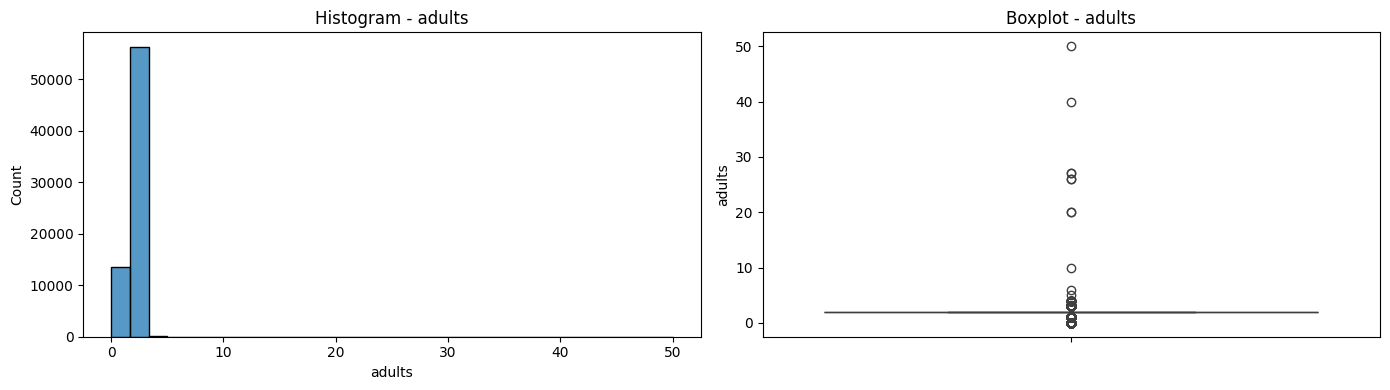

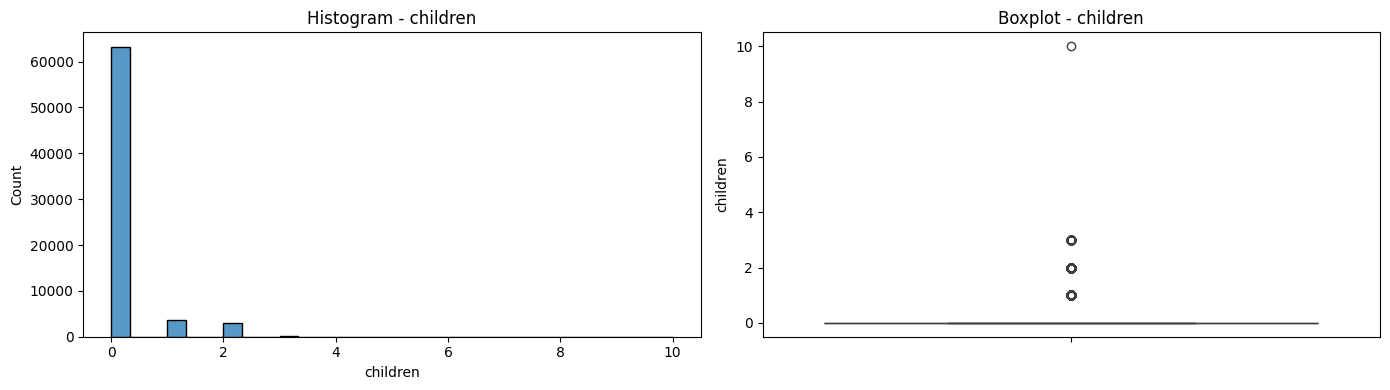

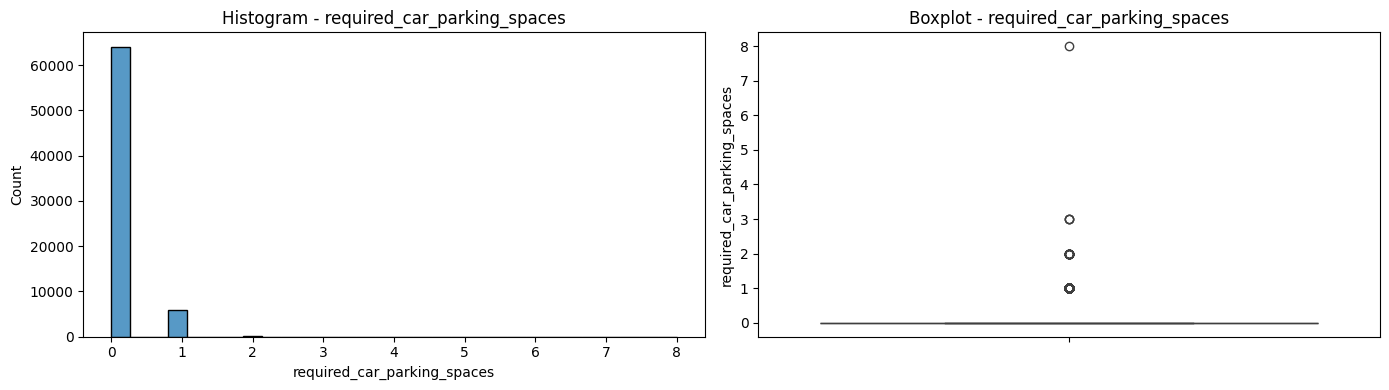

In [26]:
def diagnostic_plots(df, feature):
    plt.figure(figsize=(14, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature], bins=30)
    plt.title(f'Histogram - {feature}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot - {feature}')

    plt.tight_layout()
    plt.show()


features_to_inspect = [
    'adults',
    'children',
    'required_car_parking_spaces'
]

for col in features_to_inspect:
    diagnostic_plots(X_train, col)

### Keputusan Penanganan Outlier

Berdasarkan analisis skewness, proporsi outlier, serta visualisasi distribusi,
dapat disimpulkan bahwa tidak semua outlier pada fitur numerik perlu ditangani.

Mayoritas fitur memiliki proporsi outlier yang sangat rendah (< 1%) dan
nilai ekstrem yang masih berada dalam batas wajar konteks bisnis perhotelan.

Namun, terdapat beberapa fitur dengan karakteristik khusus:
- `adults`, `children`, dan `required_car_parking_spaces` merupakan variabel diskret
  dengan distribusi *zero-inflated*, sehingga metode IQR cenderung menandai
  nilai non-zero sebagai outlier
- Nilai ekstrem pada fitur-fitur tersebut tidak selalu merepresentasikan kesalahan data,
  melainkan kondisi bisnis yang valid (misalnya reservasi grup)

Oleh karena itu, **penanganan outlier tidak dilakukan secara agresif**.
Pendekatan yang dipilih adalah:
- Tidak menerapkan winsorization global
- Tidak menghapus observasi
- Penyesuaian nilai ekstrem hanya akan dilakukan secara selektif
  jika terbukti mengganggu stabilitas model pada tahap evaluasi

## Persiapan Preprocessing dan Pipeline Modeling

Setelah seluruh tahapan *feature engineering* selesai dilakukan, termasuk:
- penanganan missing values,
- analisis dan keputusan cardinality,
- serta analisis outlier,

langkah selanjutnya adalah menyiapkan **pipeline preprocessing** yang akan
digunakan dalam proses pemodelan.

Seluruh preprocessing dilakukan menggunakan *pipeline* untuk memastikan bahwa:
- tidak terjadi **data leakage** antara data training dan testing,
- proses transformasi konsisten di setiap fold cross-validation,
- dan pipeline dapat langsung digunakan untuk evaluasi serta deployment model.

Tahapan preprocessing yang akan diterapkan meliputi:
- **Scaling** pada fitur numerik
- **Encoding** pada fitur kategorikal
- Penggabungan seluruh transformasi menggunakan `ColumnTransformer`

### Definisi Fitur untuk Preprocessing

Berdasarkan hasil eksplorasi data, analisis missing values, cardinality, dan outlier,
fitur dibagi menjadi dua kelompok utama:

- **Fitur numerik**: fitur dengan makna kuantitatif dan urutan numerik yang jelas
- **Fitur kategorikal**: fitur dengan makna kategori tanpa urutan numerik inheren

Pembagian ini akan digunakan sebagai dasar dalam proses scaling dan encoding
menggunakan pipeline preprocessing.

In [27]:
# Fitur numerik
num_features = [
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

# Fitur kategorikal
cat_features = [
    'hotel',
    'arrival_date_month',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'country',
    'agent',
    'company'
]

### Definisi Transformer Preprocessing

Untuk memastikan seluruh fitur berada pada skala dan representasi yang sesuai,
digunakan beberapa teknik preprocessing:

- **MinMaxScaler** untuk fitur numerik  
  Digunakan karena sebagian besar fitur numerik berskala terbatas dan tidak
  berdistribusi normal.

- **One-Hot Encoding** untuk fitur kategorikal  
  Digunakan untuk menghindari asumsi ordinal pada fitur kategori.

Seluruh transformasi digabungkan menggunakan `ColumnTransformer`
agar dapat diterapkan secara konsisten dalam pipeline modeling.

In [28]:
# Scaler dan encoder
scaler = MinMaxScaler()

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ('num', scaler, num_features),
        ('cat', encoder, cat_features)
    ],
    remainder='drop'
)

# Modeling

## Pipeline Modeling Baseline

Pada tahap ini, dibangun beberapa **model baseline** untuk memprediksi
pembatalan reservasi hotel (`is_canceled`).

Tujuan utama dari modeling baseline adalah:
- Menyediakan titik awal performa model tanpa optimasi
- Membandingkan karakteristik beberapa algoritma klasifikasi
- Menentukan kandidat model yang layak untuk proses tuning

Seluruh model dibangun menggunakan **`make_pipeline`** untuk menggabungkan:
1. Tahapan preprocessing (scaling dan encoding)
2. Algoritma klasifikasi

Pendekatan pipeline digunakan untuk:
- Mencegah data leakage
- Menjaga konsistensi transformasi data
- Memastikan evaluasi model yang adil dan terstruktur

## Definisi Model Baseline

Beberapa algoritma klasifikasi digunakan sebagai model baseline, yaitu:

- **K-Nearest Neighbors (KNN)**  
  Sensitif terhadap skala fitur dan jarak antar data

- **Support Vector Machine (SVM)**  
  Efektif pada data berdimensi tinggi setelah encoding

- **Decision Tree**  
  Model berbasis aturan yang mudah diinterpretasi namun rawan overfitting

- **Random Forest**  
  Ensemble tree yang lebih stabil dan robust

- **AdaBoost**  
  Metode boosting untuk meningkatkan performa model lemah

Seluruh model menggunakan konfigurasi default (baseline)
tanpa hyperparameter tuning.

In [29]:
# Pipeline model baseline menggunakan make_pipeline

pipe_knn = make_pipeline(
    preprocess,
    KNeighborsClassifier()
)

pipe_svc = make_pipeline(
    preprocess,
    SVC()
)

pipe_dt = make_pipeline(
    preprocess,
    DecisionTreeClassifier(
        random_state=42
    )
)

pipe_rf = make_pipeline(
    preprocess,
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )
)

pipe_ada = make_pipeline(
    preprocess,
    AdaBoostClassifier(
        random_state=42
    )
)

## Kumpulan Model Baseline

Seluruh pipeline model baseline dikumpulkan dalam satu struktur
untuk memudahkan proses evaluasi menggunakan
**Stratified K-Fold Cross Validation** pada tahap selanjutnya.

In [30]:
models = {
    "KNN": pipe_knn,
    "SVC": pipe_svc,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf,
    "AdaBoost": pipe_ada
}

## Evaluasi Model Baseline

Evaluasi performa model baseline dilakukan menggunakan
**Stratified K-Fold Cross Validation** untuk memastikan
proporsi kelas target tetap seimbang pada setiap fold.

Metrik utama yang digunakan adalah **recall**, karena
kesalahan paling berisiko dalam konteks bisnis adalah
gagal mendeteksi reservasi yang berpotensi dibatalkan
(*false negative*).

Pada tahap ini:
- Tidak dilakukan hyperparameter tuning
- Tidak dipilih model terbaik terlebih dahulu
- Fokus hanya pada perbandingan performa baseline secara adil

In [31]:
# Stratified K-Fold configuration
skfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skfold,
        scoring='recall',
        n_jobs=-1
    )
    
    cv_results.append({
        'Model': name,
        'Recall Mean': scores.mean(),
        'Recall Std': scores.std()
    })

In [32]:
cv_results_df = pd.DataFrame(cv_results).sort_values(
    by='Recall Mean',
    ascending=False
)

cv_results_df

,Model,Recall Mean,Recall Std
3,Random Forest,0.649688,0.004965
2,Decision Tree,0.631270,0.009961
1,SVC,0.603486,0.013427
0,KNN,0.589438,0.005261
4,AdaBoost,0.436264,0.028378


## Pemilihan Model Baseline Terbaik

Berdasarkan hasil evaluasi menggunakan Stratified K-Fold Cross Validation
dengan metrik **recall**, dapat disimpulkan bahwa **Random Forest**
memiliki performa terbaik dibandingkan model baseline lainnya.

Random Forest menunjukkan:
- Nilai recall rata-rata tertinggi
- Variansi performa yang paling rendah antar-fold
- Stabilitas yang lebih baik dibandingkan Decision Tree tunggal
- Keseimbangan yang baik antara performa dan kompleksitas model

Oleh karena itu, **Random Forest dipilih sebagai model baseline terbaik**
dan akan digunakan pada tahap evaluasi lanjutan serta hyperparameter tuning.

## Evaluasi Random Forest Baseline

Setelah Random Forest terpilih sebagai model baseline terbaik berdasarkan
hasil Stratified K-Fold Cross Validation dengan metrik recall,
tahap selanjutnya adalah melakukan evaluasi performa model
pada **data test** yang benar-benar belum pernah dilihat sebelumnya.

Evaluasi dilakukan untuk:
- Mengukur kemampuan generalisasi model
- Membandingkan performa train vs test (indikasi overfitting)
- Menilai kemampuan model dalam mendeteksi reservasi yang dibatalkan

Metrik evaluasi yang digunakan:
- **Recall** sebagai metrik utama (fokus pada deteksi pembatalan)
- **ROC-AUC** untuk mengukur kemampuan pemisahan kelas
- **Confusion Matrix** untuk melihat kesalahan klasifikasi secara detail

In [33]:
# Train Random Forest baseline pada full training set
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'required_car_parking_spaces',
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type', 'country',
                                                   'agent', 'company'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [34]:
# Prediksi label
y_pred_train = pipe_rf.predict(X_train)
y_pred_test = pipe_rf.predict(X_test)

# Prediksi probabilitas (untuk ROC-AUC)
y_pred_train_proba = pipe_rf.predict_proba(X_train)[:, 1]
y_pred_test_proba = pipe_rf.predict_proba(X_test)[:, 1]

In [35]:
print("=== Random Forest Baseline Performance ===")
print(f"Recall Train : {recall_score(y_train, y_pred_train):.4f}")
print(f"Recall Test  : {recall_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC Train: {roc_auc_score(y_train, y_pred_train_proba):.4f}")
print(f"ROC-AUC Test : {roc_auc_score(y_test, y_pred_test_proba):.4f}")

=== Random Forest Baseline Performance ===
Recall Train : 0.9900
Recall Test  : 0.6524
ROC-AUC Train: 0.9999
ROC-AUC Test : 0.9014


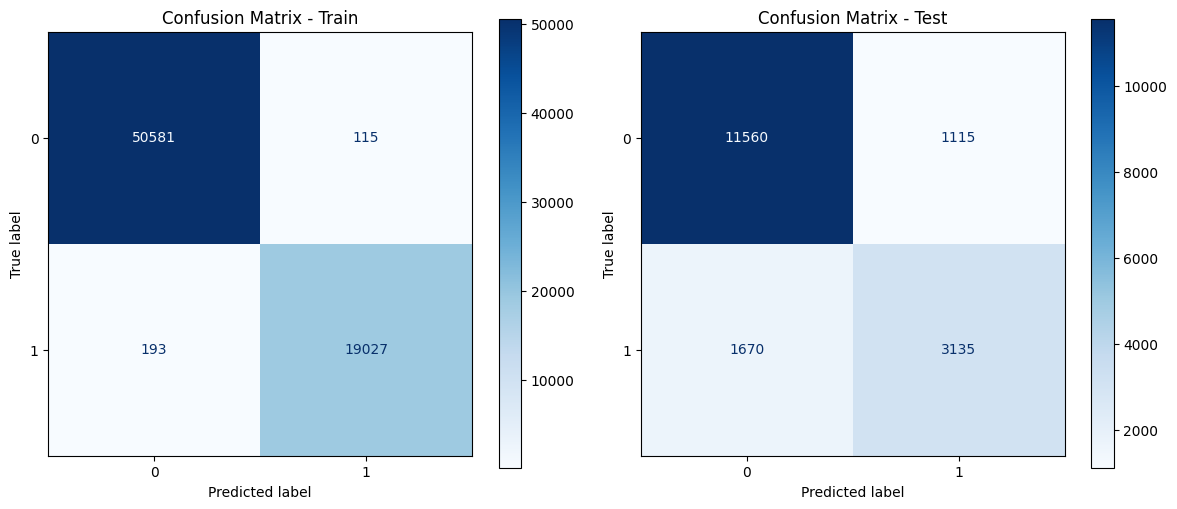

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train
ConfusionMatrixDisplay.from_estimator(
    pipe_rf, X_train, y_train,
    ax=axes[0], cmap='Blues'
)
axes[0].set_title("Confusion Matrix - Train")

# Test
ConfusionMatrixDisplay.from_estimator(
    pipe_rf, X_test, y_test,
    ax=axes[1], cmap='Blues'
)
axes[1].set_title("Confusion Matrix - Test")

plt.tight_layout()
plt.show()

## Interpretasi Evaluasi Random Forest Baseline

Hasil evaluasi menunjukkan bahwa Random Forest baseline memiliki
kemampuan yang sangat baik dalam mendeteksi pembatalan pada data latih,
namun performanya menurun pada data test.

Perbandingan performa train dan test menunjukkan bahwa:
- Recall pada data train sangat tinggi (≈ 0.99), menandakan model mampu
  mengenali hampir seluruh reservasi yang dibatalkan
- Recall pada data test menurun menjadi sekitar 0.65, mengindikasikan
  adanya **overfitting** pada model baseline
- Meskipun demikian, ROC-AUC pada data test tetap tinggi (≈ 0.90),
  yang menunjukkan bahwa model masih memiliki kemampuan yang baik
  dalam memisahkan kelas pembatalan dan non-pembatalan

Analisis confusion matrix pada data test menunjukkan bahwa masih terdapat
jumlah **false negative** yang cukup signifikan, yaitu reservasi yang
sebenarnya dibatalkan namun gagal terdeteksi oleh model.

Temuan ini mengindikasikan bahwa:
- Model baseline belum optimal dari sisi generalisasi
- Struktur pohon yang kompleks pada Random Forest baseline berkontribusi
  terhadap overfitting
- Namun, kemampuan pemeringkatan probabilitas yang baik (ROC-AUC tinggi)
  membuka peluang perbaikan melalui hyperparameter tuning dan
  penyesuaian kompleksitas model

Oleh karena itu, Random Forest baseline dipilih untuk dilanjutkan
ke tahap **hyperparameter tuning** dengan tujuan meningkatkan recall
pada data test sekaligus mengurangi overfitting.

# Hyperparameter Tuning

## Hyperparameter Tuning – Random Forest

Berdasarkan evaluasi baseline, Random Forest menunjukkan performa terbaik
dibandingkan model lain dengan nilai recall tertinggi pada cross-validation.
Namun, terdapat indikasi **overfitting**, ditunjukkan oleh perbedaan yang cukup
besar antara performa data latih dan data uji.

Tahap hyperparameter tuning dilakukan dengan tujuan:
- Mengurangi kompleksitas model untuk meningkatkan generalisasi
- Meningkatkan **recall pada data uji**
- Mempertahankan atau meningkatkan **ROC-AUC**

Optimasi difokuskan pada parameter yang secara langsung memengaruhi
kompleksitas pohon dan proses pembelajaran model.

In [37]:
param_dist = {
    'randomforestclassifier__n_estimators': [200, 300, 500],
    'randomforestclassifier__max_depth': [None, 10, 20, 30],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 5],
    'randomforestclassifier__max_features': ['sqrt', 'log2']
}

rf_tuned = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=skfold,
    scoring='recall',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train, y_train)

print("Best Parameters:")
print(rf_tuned.best_params_)

print("\nBest CV Recall:")
print(rf_tuned.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'randomforestclassifier__n_estimators': 200, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__max_depth': None}

Best CV Recall:
0.6369927159209158


## Evaluasi Hasil Hyperparameter Tuning

Hasil hyperparameter tuning menunjukkan bahwa Random Forest dengan konfigurasi
terbaik menghasilkan **nilai recall cross-validation yang lebih rendah**
dibandingkan model baseline.

| Model | CV Recall |
|------|-----------|
| Random Forest Baseline | ~0.65 |
| Random Forest Tuned | ~0.64 |

Hal ini mengindikasikan bahwa proses tuning cenderung membuat model
lebih konservatif, sehingga menurunkan sensitivitas dalam mendeteksi
reservasi yang dibatalkan.

Mengingat tujuan utama proyek ini adalah **memaksimalkan recall**
untuk meminimalkan risiko false negative (reservasi batal yang tidak terdeteksi),
maka **model Random Forest baseline dipertahankan sebagai model final**.

# Kesimpulan Exploratory Data Analysis (EDA)

Tahap *Exploratory Data Analysis* (EDA) dilakukan untuk memahami karakteristik data,
pola pembatalan reservasi, serta potensi permasalahan data yang dapat memengaruhi
proses pemodelan.

Beberapa temuan utama dari EDA adalah sebagai berikut:

### 1. Distribusi Target Tidak Seimbang
Target `is_canceled` menunjukkan ketidakseimbangan kelas, di mana reservasi
**tidak dibatalkan** mendominasi dataset. Kondisi ini menuntut pemilihan metrik
evaluasi yang tepat, karena akurasi saja tidak cukup merepresentasikan performa model.

### 2. Faktor Waktu dan Perilaku Pemesanan Berpengaruh
Fitur-fitur seperti:
- `lead_time`
- `total_of_special_requests`
- `deposit_type`
- `market_segment`

menunjukkan hubungan yang kuat dengan kemungkinan pembatalan. Reservasi dengan
lead time panjang dan tanpa deposit cenderung memiliki risiko pembatalan lebih tinggi.

### 3. Banyak Fitur Bersifat Diskret dan Zero-Inflated
Beberapa fitur numerik seperti `children`, `required_car_parking_spaces`,
dan `previous_cancellations` didominasi oleh nilai nol. Kondisi ini menyebabkan
distribusi yang sangat skewed dan perlu ditangani secara hati-hati agar tidak
menghilangkan makna bisnis dari nilai non-zero.

### 4. Tingginya Cardinality pada Beberapa Fitur Kategorikal
Fitur seperti `agent`, `company`, dan `country` memiliki cardinality tinggi.
Hal ini berpotensi meningkatkan kompleksitas model setelah encoding dan
meningkatkan risiko overfitting apabila tidak dikendalikan melalui pipeline
dan evaluasi berbasis cross-validation.

Secara keseluruhan, EDA menunjukkan bahwa dataset memiliki kompleksitas tinggi
baik dari sisi distribusi, struktur kategorikal, maupun potensi bias,
sehingga pendekatan modeling perlu dilakukan secara sistematis dan terkontrol.

# Kesimpulan Analisis Model dan Modeling

Tahap modeling dilakukan secara bertahap, dimulai dari evaluasi beberapa model
baseline hingga proses hyperparameter tuning pada model dengan performa terbaik.

### 1. Perbandingan Model Baseline
Berdasarkan evaluasi menggunakan **Stratified K-Fold Cross Validation**
dengan metrik **recall**, diperoleh hasil bahwa:
- Random Forest memiliki nilai recall rata-rata tertinggi
- Variansi performa antar-fold relatif kecil
- Model berbasis pohon mengungguli model berbasis jarak

Hal ini menunjukkan bahwa pola pembatalan bersifat non-linear dan lebih efektif
ditangkap oleh model ensemble berbasis tree.

### 2. Evaluasi Random Forest Baseline
Evaluasi pada data latih dan data uji menunjukkan:
- Recall sangat tinggi pada data latih (≈ 0.99)
- Recall menurun pada data uji (≈ 0.65)
- ROC-AUC pada data uji tetap tinggi (≈ 0.90)

Perbedaan ini mengindikasikan adanya **overfitting**, namun juga menunjukkan
bahwa model memiliki kemampuan pemisahan kelas yang baik secara probabilistik.

### 3. Hasil Hyperparameter Tuning
Hyperparameter tuning dilakukan untuk mengurangi kompleksitas model dan
meningkatkan generalisasi. Namun, hasil tuning menunjukkan bahwa
nilai recall cross-validation sedikit lebih rendah dibandingkan baseline.

Hal ini mengindikasikan bahwa proses tuning membuat model lebih konservatif
dan justru menurunkan sensitivitas dalam mendeteksi pembatalan.

### 4. Pemilihan Model Final
Karena tujuan utama proyek ini adalah **memaksimalkan recall**,
maka **Random Forest baseline dipilih sebagai model final**.

Keputusan ini didasarkan pada:
- Recall tertinggi pada evaluasi baseline
- Stabilitas performa antar-fold
- Tidak adanya peningkatan recall dari proses tuning

Pendekatan ini menekankan bahwa model terbaik tidak selalu
merupakan model yang paling kompleks, melainkan yang paling
selaras dengan tujuan bisnis.

# Business Insight dan Implikasi

Berdasarkan hasil EDA dan modeling, diperoleh beberapa insight penting
yang relevan untuk pengambilan keputusan bisnis di industri perhotelan.

### 1. Deteksi Dini Reservasi Berisiko Tinggi
Model mampu mengidentifikasi reservasi yang berpotensi dibatalkan
dengan tingkat recall yang cukup tinggi. Hal ini memungkinkan hotel untuk:
- Mengantisipasi pembatalan sejak awal
- Mengelola inventory kamar secara lebih proaktif
- Mengurangi potensi kehilangan pendapatan

### 2. Optimalisasi Kebijakan Deposit dan Lead Time
Fitur `deposit_type` dan `lead_time` terbukti berpengaruh besar
terhadap pembatalan reservasi. Insight ini dapat dimanfaatkan untuk:
- Menyesuaikan kebijakan deposit pada reservasi berisiko tinggi
- Memberikan insentif pada reservasi dengan lead time panjang

### 3. Segmentasi Pelanggan yang Lebih Tepat
Perbedaan tingkat pembatalan antar `market_segment` menunjukkan bahwa
pendekatan satu strategi untuk semua segmen kurang optimal.
Hotel dapat menerapkan strategi komunikasi dan penawaran
yang lebih spesifik berdasarkan segmen pelanggan.

### 4. Trade-off antara Recall dan Operasional
Fokus pada recall berarti model cenderung menghasilkan lebih banyak
*false positive*. Namun, dalam konteks bisnis, pendekatan ini lebih aman
dibandingkan melewatkan reservasi yang benar-benar akan dibatalkan.

---

# Kesimpulan Akhir

Proyek ini menunjukkan bahwa pendekatan yang sistematis,
dimulai dari pemahaman data, evaluasi baseline yang adil,
hingga pemilihan model berbasis tujuan bisnis,
lebih penting dibandingkan sekadar mengejar kompleksitas model.

Random Forest baseline dipilih sebagai model final karena memberikan
keseimbangan terbaik antara performa, stabilitas, dan relevansi bisnis.

# Model Saving

In [38]:
with open("rf_baseline_pipeline.pkl", "wb") as f:
    pickle.dump(pipe_rf, f)